# RED NEURONAL PARA ENTRENAMIENTO DE CLASIFICACIÓN DE CHURN EN EMPRESA DE TELECOMUNICACIONES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/telco_data_transformed.csv').dropna()
df.head(10)

,gender,partner,dependents,phone_service,paperless_billing,churn,device_protection_no,device_protection_noservice,device_protection_yes,movies_no,...,security_no,security_noservice,security_yes,internet_dsl,internet_fiber,internet_no,senior_citizen,tenure,monthly_charges,total_charges
0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,29.85,29.85
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,34.0,56.95,1889.50
2,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,2.0,53.85,108.15
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,45.0,42.30,1840.75
4,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,70.70,151.65
5,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,8.0,99.65,820.50
6,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,22.0,89.10,1949.40
7,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,10.0,29.75,301.90
8,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,28.0,104.80,3046.05
9,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,62.0,56.15,3487.95


In [4]:
df.isnull().sum().sum()

np.int64(0)

In [5]:
corr_matrix = df.corr()
corr_churn = corr_matrix[['churn']].sort_values(by='churn',ascending=False)
corr_churn

,churn
churn,1.000000
contract_month,0.404565
security_no,0.342235
tech_support_no,0.336877
internet_fiber,0.307463
payment_check,0.301455
backup_no,0.267595
device_protection_no,0.252056
monthly_charges,0.192858
paperless_billing,0.191454


In [6]:
cols = corr_churn.index.tolist()
cols.remove('churn')
cols

['contract_month',
 'security_no',
 'tech_support_no',
 'internet_fiber',
 'payment_check',
 'backup_no',
 'device_protection_no',
 'monthly_charges',
 'paperless_billing',
 'senior_citizen',
 'movies_no',
 'tv_no',
 'tv_yes',
 'movies_yes',
 'multiple_lines_yes',
 'phone_service',
 'gender',
 'multiple_lines_noservice',
 'multiple_lines_no',
 'device_protection_yes',
 'backup_yes',
 'payment_mail',
 'payment_transfer',
 'internet_dsl',
 'payment_creditcard',
 'partner',
 'dependents',
 'tech_support_yes',
 'security_yes',
 'contract_year',
 'total_charges',
 'device_protection_noservice',
 'security_noservice',
 'tech_support_noservice',
 'movies_noservice',
 'tv__no internet service',
 'internet_no',
 'backup_noservice',
 'contract_twoyears',
 'tenure']

In [7]:
X = df[cols].values
y = df['churn'].values.reshape(-1,1)

# CREAR RED NEURONAL

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import Input

In [20]:
from tensorflow.keras.layers import Dropout

In [29]:
red = Sequential()
inputs = Input(shape=(40,))
entrada = Dense(units=100,activation='relu')
oculta1 = Dense(units=100,activation='relu')
oculta2 = Dense(units=100,activation='relu')
salida = Dense(units=1,activation='sigmoid')

In [30]:
red.add(inputs)
red.add(entrada)
red.add(oculta1)
red.add(Dropout(0.5))
red.add(oculta2)
red.add(salida)

red

<Sequential name=sequential_3, built=True>

In [31]:
red.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [32]:
model1 = red.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=100,
    validation_data=(X_test,y_test)
)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.7719 - loss: 0.4766 - val_accuracy: 0.7896 - val_loss: 0.4410
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7924 - loss: 0.4307 - val_accuracy: 0.7974 - val_loss: 0.4348
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7993 - loss: 0.4245 - val_accuracy: 0.7982 - val_loss: 0.4380
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8037 - loss: 0.4180 - val_accuracy: 0.7932 - val_loss: 0.4375
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8052 - loss: 0.4128 - val_accuracy: 0.7974 - val_loss: 0.4383
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8066 - loss: 0.4093 - val_accuracy: 0.7896 - val_loss: 0.4322
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8066 - loss: 0.4113 - val_accuracy: 0.7996 - val_loss: 0.4336
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8121 - loss: 0.4029 - val_accuracy: 0.7939 - val_loss

In [33]:
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay

y_pred = red.predict(X_test)
y_pred = np.round(y_pred)

score = accuracy_score(y_test,y_pred)
print(f'el accuracy es {score}')

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
el accuracy es 0.7917555081734187


<Figure size 1100x1100 with 0 Axes>

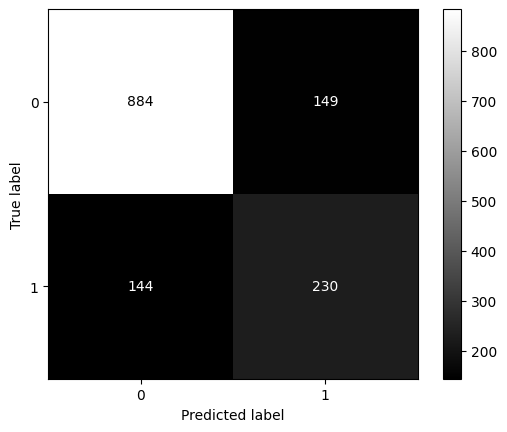

In [34]:
matrix = confusion_matrix(y_test,y_pred)
fig = plt.figure(figsize=(11,11))
cm = matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='gray')
plt.show()

In [35]:
def plot_overfitting(history):
    epochs = range(1, len(history.history['loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Pérdida
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['loss'], label='Pérdida de entrenamiento')
    plt.plot(epochs, history.history['val_loss'], label='Pérdida de validación')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.title('Pérdida en entrenamiento vs validación')

    # Precisión
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['accuracy'], label='Precisión de entrenamiento')
    plt.plot(epochs, history.history['val_accuracy'], label='Precisión de validación')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()
    plt.title('Precisión en entrenamiento vs validación')

    plt.show()

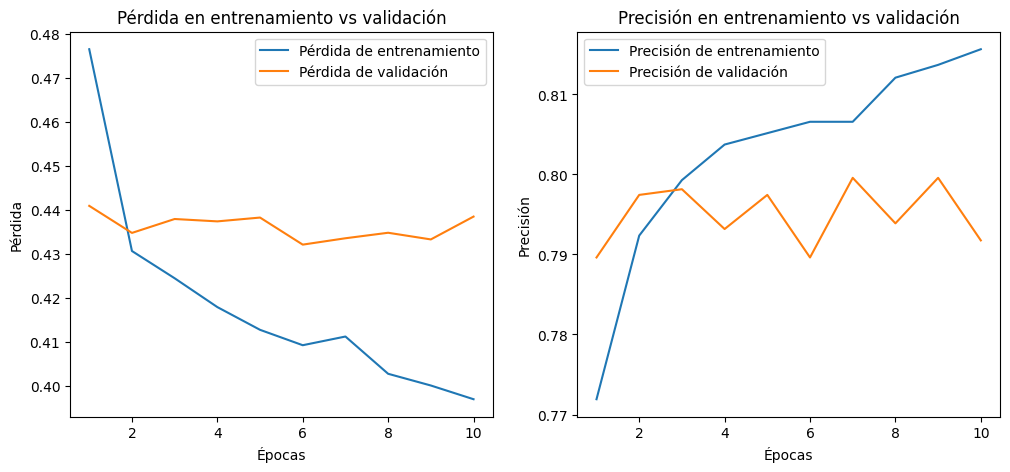

In [36]:
plot_overfitting(model1)

# UTILIZAMOS KERAS TUNER

In [38]:
!pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.0 MB/s eta 0:00:00


In [42]:
import keras_tuner as kt

In [43]:
def build_model(hp):
  model = keras.Sequential()
  model.add(keras.layers.Dense(hp.Int("units1", min_value=8, max_value=64, step=8), activation="relu", input_shape=(X_train.shape[1],)))
  model.add(keras.layers.Dense(hp.Int("units2",min_value=8,max_value=64,step=8),activation='relu'))
  model.add(keras.layers.Dense(1,activation='sigmoid'))

  model.compile(
      optimizer=keras.optimizers.Adam(hp.Choice("learning_rate",[0.001,0.01,0.1])),
      loss='binary_crossentropy',
      metrics=['accuracy']
  )
  return model

In [44]:
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=20,
    factor=3,
    directory='kt_search',
    project_name='telco_churn'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [45]:
tuner.search(X_train,y_train,epochs=20,validation_data=(X_test,y_test))

Trial 30 Complete [00h 00m 18s]
val_accuracy: 0.7768301367759705

Best val_accuracy So Far: 0.8009950518608093
Total elapsed time: 00h 04m 43s


In [46]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Mejor configuración: {best_hps.values}")

Mejor configuración: {'units1': 8, 'units2': 16, 'learning_rate': 0.01, 'tuner/epochs': 20, 'tuner/initial_epoch': 7, 'tuner/bracket': 1, 'tuner/round': 1, 'tuner/trial_id': '0019'}


In [48]:
best_model = tuner.hypermodel.build(best_hps)
best_model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test))

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7819 - loss: 0.4449 - val_accuracy: 0.7790 - val_loss: 0.4460
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8000 - loss: 0.4235 - val_accuracy: 0.7903 - val_loss: 0.4403
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8030 - loss: 0.4180 - val_accuracy: 0.8031 - val_loss: 0.4323
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8034 - loss: 0.4143 - val_accuracy: 0.7960 - val_loss: 0.4370
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8101 - loss: 0.4136 - val_accuracy: 0.7967 - val_loss: 0.4385
Epoch 6/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8055 - loss: 0.4130 - val_accuracy: 0.7903 - val_loss: 0.4391
Epoch 7/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8068 - loss: 0.4118 - val_accuracy: 0.7939 - val_loss: 0.4349
Epoch 8/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8089 - loss: 0.4106 - val_accuracy: 0.7882 - va

In [50]:
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

y_pred = best_model.predict(X_test)
y_pred = np.round(y_pred)

score = accuracy_score(y_test,y_pred)
print(f'el accuracy es {score}')

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
el accuracy es 0.7889125799573561


<Figure size 1100x1100 with 0 Axes>

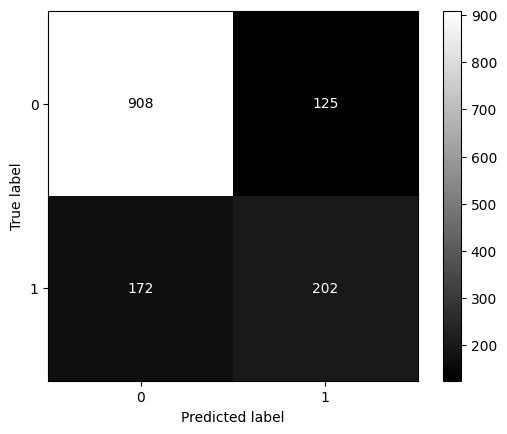

In [51]:
matrix = confusion_matrix(y_test,y_pred)
fig = plt.figure(figsize=(11,11))
cm = matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='gray')
plt.show()